In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils import class_weight

In [3]:
BASE_PATH = 'G:/VoiceMaster'
DATASET_PATHS = {
    'RAVDESS': os.path.join(BASE_PATH, 'RAVDESS'),
    'CREMA-D': os.path.join(BASE_PATH, 'CREMA-D'),
    'TESS': os.path.join(BASE_PATH, 'TESS'),
    'SAVEE': os.path.join(BASE_PATH, 'SAVEE')
}

SR = 22050
DURATION_TOTAL = 3.0   # Độ dài file gốc quy ước
WIN_LEN_SEC = 1.0      # Độ dài cửa sổ cắt
STRIDE_SEC = 0.5       # Bước trượt
RMS_THRESHOLD = 0.005  # Ngưỡng lọc im lặng

FRAME_LEN = int(WIN_LEN_SEC * SR)
HOP_LEN_SAMPLES = int(STRIDE_SEC * SR)
N_MELS = 128
MEL_TIME_STEPS = int(np.ceil(FRAME_LEN / 512))

In [4]:
FINAL_EMOTIONS = ['Angry','Fear', 'Neutral']

RAVDESS_MAP = {'01':'Neutral','02':'Calm','05':'Angry','06':'Fear','08': 'Fear'}
CREMAD_MAP = {'ANG':'Angry','FEA':'Fear','NEU':'Neutral'}
TESS_MAP = {'angry':'Angry','fear':'Fear','neutral':'Neutral','surprise':'Fear'}
SAVEE_MAP = {'a':'Angry','f':'Fear','n':'Neutral','su':'Fear'}


def extract_ravdess(file_path):
    parts = os.path.basename(file_path).split('-')
    if len(parts) < 7: return None
    emotion = RAVDESS_MAP.get(parts[2])
    if emotion in FINAL_EMOTIONS:
        return {'File_Path': file_path, 'Emotion': emotion, 'Speaker_ID': f"R_{parts[6].split('.')[0]}"}
    return None

def extract_cremad(file_path):
    parts = os.path.basename(file_path).split('_')
    if len(parts) < 3: return None
    emotion = CREMAD_MAP.get(parts[2])
    if emotion in FINAL_EMOTIONS:
        return {'File_Path': file_path, 'Emotion': emotion, 'Speaker_ID': f"C_{parts[0]}"}
    return None

def extract_tess(file_path):
    parts = os.path.basename(file_path).split('_')
    if len(parts) < 2: return None
    emotion_raw = parts[-1].split('.')[0].lower()
    emotion = TESS_MAP.get(emotion_raw)
    if emotion in FINAL_EMOTIONS:
        return {'File_Path': file_path, 'Emotion': emotion, 'Speaker_ID': f"T_{parts[0]}"}
    return None

def extract_savee(file_path):
    filename = os.path.basename(file_path).lower()
    speaker = os.path.basename(os.path.dirname(file_path)).upper() # Lấy tên thư mục cha làm Speaker (DC, JE...)
    if speaker not in ['DC', 'JE', 'KL', 'TM', 'JK']: return None # Lọc thư mục rác

    code = filename[:2] if filename[:2] in SAVEE_MAP else filename[:1]
    emotion = SAVEE_MAP.get(code)
    if emotion in FINAL_EMOTIONS:
        return {'File_Path': file_path, 'Emotion': emotion, 'Speaker_ID': f"S_{speaker}"}
    return None

def integrate_datasets():
    data = []
    funcs = {'RAVDESS': extract_ravdess, 'CREMA-D': extract_cremad, 'TESS': extract_tess, 'SAVEE': extract_savee}

    print("\n--- ĐANG QUÉT DỮ LIỆU ---")
    for name, path in DATASET_PATHS.items():
        if not os.path.exists(path): continue
        count = 0
        for root, _, files in os.walk(path):
            for f in files:
                if f.endswith('.wav'):
                    meta = funcs[name](os.path.join(root, f))
                    if meta:
                        data.append(meta)
                        count += 1
        print(f"Dataset {name}: {count} files")
    return pd.DataFrame(data)



In [5]:
def process_audio_segment(y_segment):
    """Chuyển đổi 1 đoạn raw audio thành Mel-spectrogram"""
    mel_spec = librosa.feature.melspectrogram(y=y_segment, sr=SR, n_mels=N_MELS)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Padding/Truncating chính xác
    if mel_spec_db.shape[1] < MEL_TIME_STEPS:
        pad = MEL_TIME_STEPS - mel_spec_db.shape[1]
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad)), mode='constant')
    else:
        mel_spec_db = mel_spec_db[:, :MEL_TIME_STEPS]
    return mel_spec_db

def extract_features_with_sliding_window(dataframe, desc="Processing"):
    X_list, y_list = [], []
    skipped = 0
    total = len(dataframe)

    print(f"\nĐang xử lý: {desc}")
    for idx, row in dataframe.iterrows():
        try:
            emotion = row['Emotion']
            y, _ = librosa.load(row['File_Path'], sr=SR, duration=DURATION_TOTAL)
            target_len = int(DURATION_TOTAL * SR)
            if len(y) < target_len: y = librosa.util.fix_length(y, size=target_len)

            windows = librosa.util.frame(y, frame_length=FRAME_LEN, hop_length=HOP_LEN_SAMPLES).T

            for segment in windows:
                rms = np.sqrt(np.mean(segment**2))
                if rms < RMS_THRESHOLD:
                    skipped += 1
                    continue
                
                X_list.append(process_audio_segment(segment))
                y_list.append(emotion)

        except Exception as e: print(f"Error {row['File_Path']}: {e}")

        if (idx+1) % 500 == 0: print(f"Đã xử lý {idx+1}/{total} files gốc...")

    print(f"-> Hoàn tất. Tổng mẫu : {len(X_list)}")
    return np.array(X_list), np.array(y_list)



In [6]:
def plot_training_history(history, model_name):
    """Vẽ biểu đồ Loss và Accuracy qua các epoch"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    # 1. Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title(f'{model_name} - Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title(f'{model_name} - Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    plt.show()

def visualize_all_emotions(X_data, y_data, sr=SR, classes=FINAL_EMOTIONS):
    print("Đang tổng hợp Spectrogram cho tất cả các loại cảm xúc...")
    
    y_integers = np.argmax(y_data, axis=1)
    
    for i, emotion_name in enumerate(classes):
        
        indices = np.where(y_integers == i)[0]
        
        if len(indices) > 0:
            idx = np.random.choice(indices)
            

            plt.figure(figsize=(12, 5))
            

            spec = X_data[idx].squeeze()
            if spec.shape[0] != 128 and spec.shape[1] == 128:
                spec = spec.T


            librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='mel', 
                                     fmax=sr/2, cmap='magma')
            
            plt.colorbar(format='%+2.0f dB')
            plt.title(f"Emotion: {emotion_name} (Sample Index: {idx})", fontsize=14)
            plt.tight_layout()
            plt.show()
            
        else:
            print(f"Không tìm thấy dữ liệu nào cho cảm xúc: {emotion_name}")

def plot_confusion_matrix_custom(model, X_test, y_test, model_name):
    """Vẽ ma trận nhầm lẫn để biết model hay nhầm cảm xúc nào với nhau"""

    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)
    

    cm = confusion_matrix(y_true, y_pred_classes)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=FINAL_EMOTIONS, yticklabels=FINAL_EMOTIONS)
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (True)')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

In [7]:
DATA_FILE = 'processed_audio_data(sad-neutral, fear-surprise, angry-disgust).npz' # Tên file để lưu

if os.path.exists(DATA_FILE):
    print(f"\n✅ Tìm thấy file dữ liệu đã xử lý: {DATA_FILE}")
    print(">> Đang load dữ liệu")

    data = np.load(DATA_FILE)
    X_train_norm = data['X_train']
    y_train = data['y_train']
    X_test_norm = data['X_test']
    y_test = data['y_test']

    print(">> Load xong! Sẵn sàng train.")

else:
    print(f"\nChưa thấy file {DATA_FILE}. Bắt đầu xử lý lại từ đầu...")

    df_metadata = integrate_datasets()

    unique_speakers = df_metadata['Speaker_ID'].unique()
    train_spk, test_spk = train_test_split(unique_speakers, test_size=0.2, random_state=42)

    train_df = df_metadata[df_metadata['Speaker_ID'].isin(train_spk)]
    test_df = df_metadata[df_metadata['Speaker_ID'].isin(test_spk)]

    X_train, y_train_raw = extract_features_with_sliding_window(train_df, "TRAIN SET")
    X_test, y_test_raw = extract_features_with_sliding_window(test_df, "TEST SET")

    mean = np.mean(X_train)
    std = np.std(X_train)
    X_train_norm = (X_train - mean) / std
    X_test_norm = (X_test - mean) / std

    lb = LabelEncoder()
    y_train = tf.keras.utils.to_categorical(lb.fit_transform(y_train_raw))
    y_test = tf.keras.utils.to_categorical(lb.transform(y_test_raw))

    print(f"\nĐang lưu dữ liệu vào file '{DATA_FILE}' ")
    np.savez_compressed(DATA_FILE,
                        X_train=X_train_norm,
                        y_train=y_train,
                        X_test=X_test_norm,
                        y_test=y_test)
    print("Đã lưu")


✅ Tìm thấy file dữ liệu đã xử lý: processed_audio_data(sad-neutral, fear-surprise, angry-disgust).npz
>> Đang load dữ liệu
>> Load xong! Sẵn sàng train.


In [8]:
import gc
X_train_cnn = X_train_norm.reshape(X_train_norm.shape[0], N_MELS, MEL_TIME_STEPS, 1)
X_test_cnn = X_test_norm.reshape(X_test_norm.shape[0], N_MELS, MEL_TIME_STEPS, 1)
cnn_input_shape = X_train_cnn.shape[1:]
X_train_lstm = X_train_norm.transpose(0, 2, 1)
X_test_lstm = X_test_norm.transpose(0, 2, 1)

lstm_input_shape = X_train_lstm.shape[1:]

steps = X_train_lstm.shape[1] # 44
feats = X_train_lstm.shape[2] # 128
X_train_hybrid = X_train_lstm.reshape(X_train_lstm.shape[0], 1, steps, feats)
X_test_hybrid = X_test_lstm.reshape(X_test_lstm.shape[0], 1, steps, feats)
hybrid_input_shape = X_train_hybrid.shape[1:]

print(f"\nShape chuẩn bị xong:")
print(f"CNN Input: {cnn_input_shape}")
print(f"LSTM Input: {lstm_input_shape}")
print(f"Hybrid Input: {hybrid_input_shape}")


Shape chuẩn bị xong:
CNN Input: (128, 44, 1)
LSTM Input: (44, 128)
Hybrid Input: (1, 44, 128)


Input shape cho RF/MLP: (22735, 5632)
1    8549
0    7728
2    6458
Name: count, dtype: int64

hiển thị mẫu Mel Spectrogram...
Đang tổng hợp Spectrogram cho tất cả các loại cảm xúc...


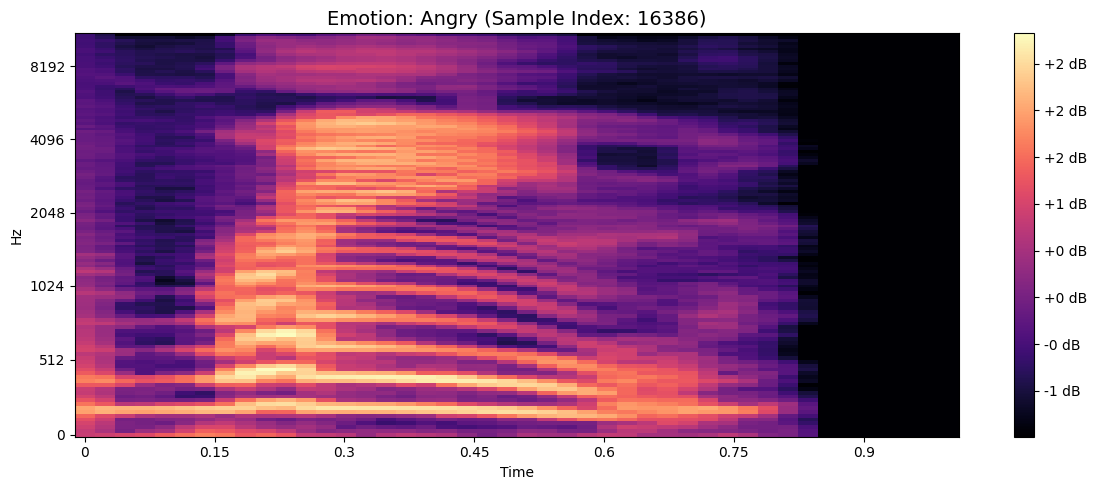

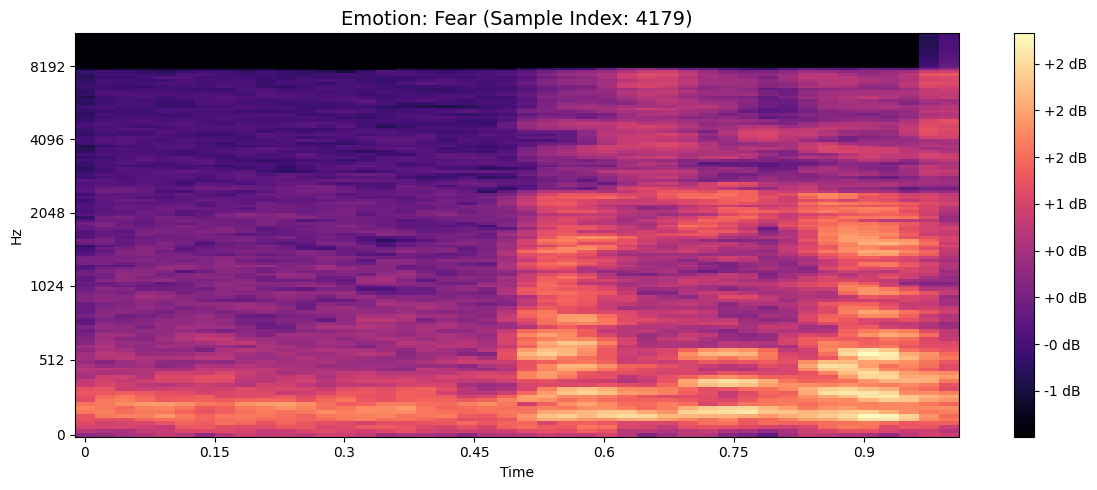

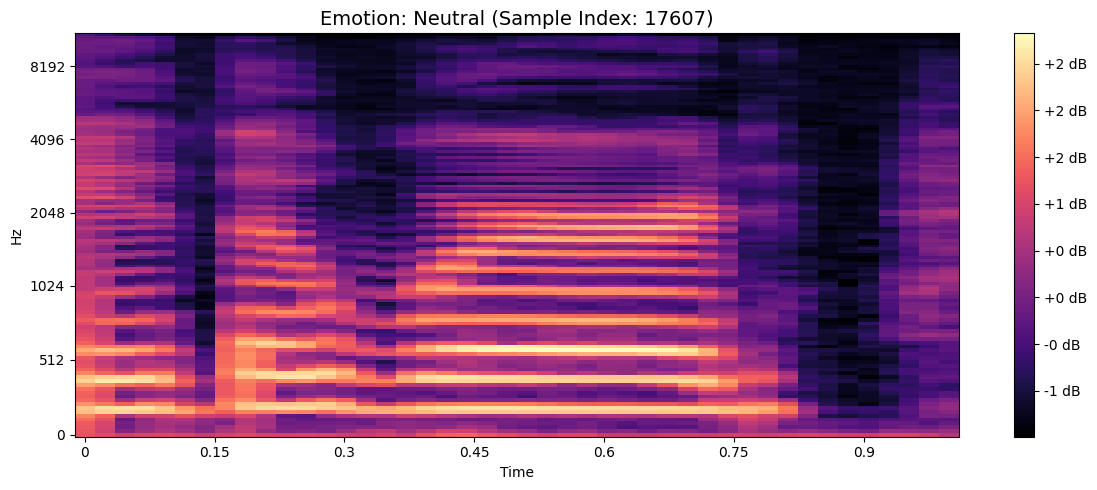


=== Training CNN-2D ===
Epoch 1/80
711/711 [==============================] - 16s 16ms/step - loss: 0.7492 - accuracy: 0.6282 - val_loss: 0.6868 - val_accuracy: 0.6832 - lr: 5.0000e-04
Epoch 2/80
711/711 [==============================] - 10s 14ms/step - loss: 0.5556 - accuracy: 0.7464 - val_loss: 0.5642 - val_accuracy: 0.7375 - lr: 5.0000e-04
Epoch 3/80
711/711 [==============================] - 10s 15ms/step - loss: 0.5039 - accuracy: 0.7763 - val_loss: 0.4275 - val_accuracy: 0.8119 - lr: 5.0000e-04
Epoch 4/80
711/711 [==============================] - 10s 15ms/step - loss: 0.4620 - accuracy: 0.7954 - val_loss: 0.6094 - val_accuracy: 0.7330 - lr: 5.0000e-04
Epoch 5/80
711/711 [==============================] - 10s 15ms/step - loss: 0.4194 - accuracy: 0.8157 - val_loss: 0.5073 - val_accuracy: 0.7842 - lr: 5.0000e-04
Epoch 6/80
711/711 [==============================] - 11s 15ms/step - loss: 0.3933 - accuracy: 0.8287 - val_loss: 0.4141 - val_accuracy: 0.8167 - lr: 5.0000e-04
Epoch 7/8

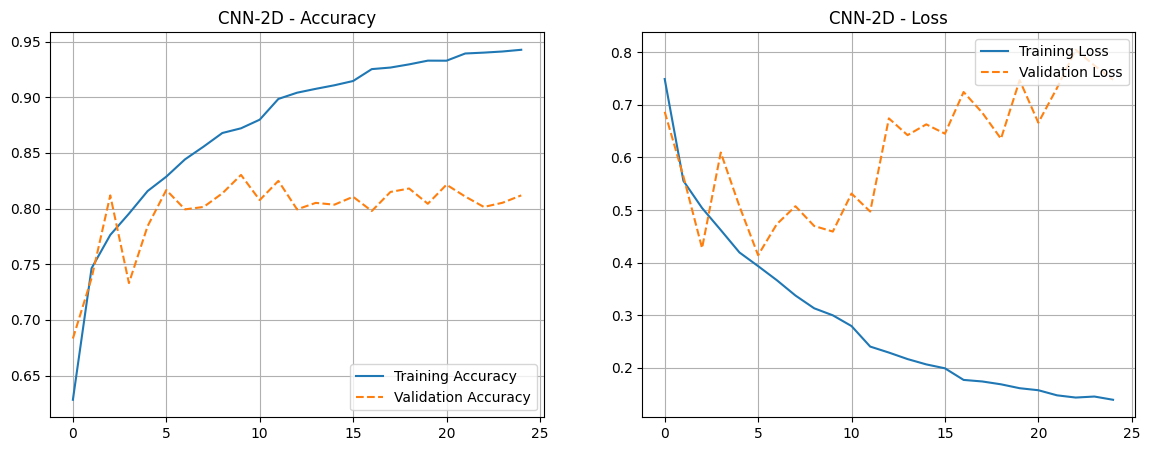

In [9]:
# MODEL & TRAINING
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

y_train_int = np.argmax(y_train, axis=1)
y_test_int = np.argmax(y_test, axis=1)

results = {}

print(f"Input shape cho RF/MLP: {X_train_flat.shape}")



# TRAIN
def train_eval_model(model, X_tr, y_tr, X_te, y_te, name):
    print(f"\n=== Training {name} ===")
    tf.keras.backend.clear_session()
    gc.collect()

    batch_size = 32

    # SETUP DATASET
    def load_data_wrapper(idx):
        i = int(idx) 
        return X_tr[i].astype(np.float32), y_tr[i].astype(np.float32)

    def load_data_val_wrapper(idx):
        i = int(idx)
        return X_te[i].astype(np.float32), y_te[i].astype(np.float32)

    def tf_mapper_train(idx):
        x, y = tf.numpy_function(load_data_wrapper, [idx], [tf.float32, tf.float32])
        x.set_shape(X_tr.shape[1:]) 
        y.set_shape(y_tr.shape[1:])
        return x, y

    def tf_mapper_val(idx):
        x, y = tf.numpy_function(load_data_val_wrapper, [idx], [tf.float32, tf.float32])
        x.set_shape(X_te.shape[1:])
        y.set_shape(y_te.shape[1:])
        return x, y

    train_dataset = tf.data.Dataset.range(len(X_tr)).shuffle(len(X_tr))
    train_dataset = train_dataset.map(tf_mapper_train, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_dataset = tf.data.Dataset.range(len(X_te))
    val_dataset = val_dataset.map(tf_mapper_val, num_parallel_calls=tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # COMPILE 
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
                  loss='categorical_crossentropy', metrics=['accuracy'])
    
    early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=0)

    # TRAIN
    try:
        history = model.fit(train_dataset, epochs=80, validation_data=val_dataset,class_weight=class_weight_dict,
                            callbacks=[early_stop, reduce_lr], verbose=1)
    except Exception as e:
        print(f"Lỗi: {e}")
        return None, 0.0, None

    # PREDICT & EVALUATE
    with tf.device('/cpu:0'):
        y_pred_probs = model.predict(val_dataset, verbose=0)
        
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = np.argmax(y_te, axis=1)
        limit = min(len(y_true), len(y_pred))
        acc = accuracy_score(y_true[:limit], y_pred[:limit])

    print(f" >> Độ chính xác {name}: {acc:.4f}")
    
    del model, train_dataset, val_dataset
    tf.keras.backend.clear_session()
    gc.collect()

    return history, acc, y_pred_probs


y_train_integers = np.argmax(y_train, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

class_weight_dict = dict(enumerate(class_weights))



print(pd.Series(np.argmax(y_train, axis=1)).value_counts())
# CNN 2D
print("\nhiển thị mẫu Mel Spectrogram...")
visualize_all_emotions(X_train_cnn, y_train)
cnn = models.Sequential([
    layers.Input(shape=cnn_input_shape),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.2),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.2),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.25),
    layers.Dense(len(FINAL_EMOTIONS), activation='softmax')
])
history_cnn, acc_cnn, preds_cnn = train_eval_model(cnn, X_train_cnn, y_train, X_test_cnn, y_test, "CNN-2D")

results['CNN-2D'] = acc_cnn
plot_training_history(history_cnn, "CNN-2D")


=== Training LSTM ===
Epoch 1/80
711/711 [==============================] - 8s 8ms/step - loss: 0.7376 - accuracy: 0.6467 - val_loss: 0.8175 - val_accuracy: 0.6435 - lr: 5.0000e-04
Epoch 2/80
711/711 [==============================] - 5s 7ms/step - loss: 0.5548 - accuracy: 0.7487 - val_loss: 0.8256 - val_accuracy: 0.6632 - lr: 5.0000e-04
Epoch 3/80
711/711 [==============================] - 6s 9ms/step - loss: 0.4902 - accuracy: 0.7806 - val_loss: 0.9583 - val_accuracy: 0.6631 - lr: 5.0000e-04
Epoch 4/80
711/711 [==============================] - 7s 9ms/step - loss: 0.4427 - accuracy: 0.8056 - val_loss: 1.0416 - val_accuracy: 0.6636 - lr: 5.0000e-04
Epoch 5/80
711/711 [==============================] - 6s 8ms/step - loss: 0.4090 - accuracy: 0.8213 - val_loss: 1.0009 - val_accuracy: 0.6747 - lr: 5.0000e-04
Epoch 6/80
711/711 [==============================] - 6s 8ms/step - loss: 0.3862 - accuracy: 0.8314 - val_loss: 0.9690 - val_accuracy: 0.7030 - lr: 5.0000e-04
Epoch 7/80
711/711 [===

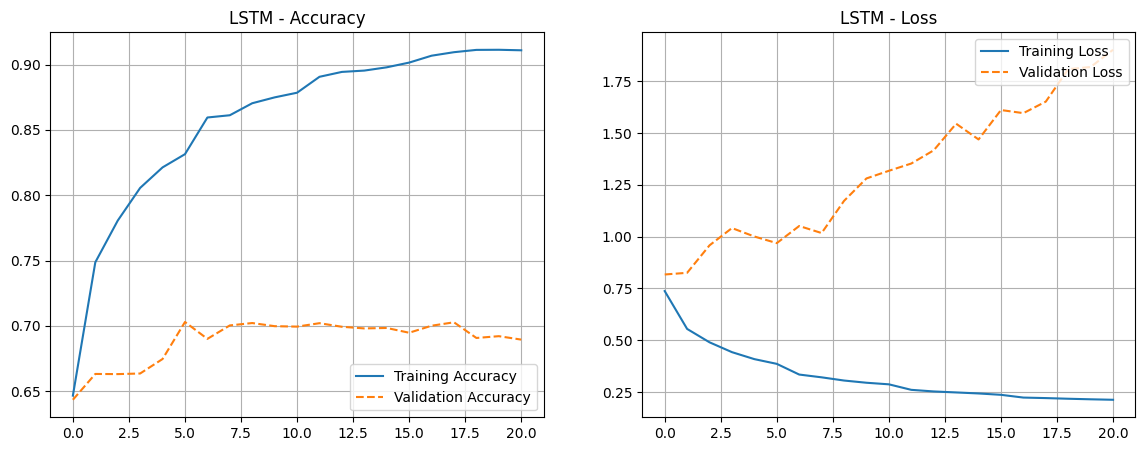

In [10]:
# MODEL LSTM
lstm = models.Sequential([
    layers.Input(shape=lstm_input_shape),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(FINAL_EMOTIONS), activation='softmax')
])
history_lstm, acc_lstm, preds_lstm = train_eval_model(lstm, X_train_lstm, y_train, X_test_lstm, y_test, "LSTM")
results['LSTM'] = acc_lstm

plot_training_history(history_lstm, "LSTM")


=== Training Hybrid ===
Epoch 1/80
711/711 [==============================] - 7s 7ms/step - loss: 0.6941 - accuracy: 0.6774 - val_loss: 0.6959 - val_accuracy: 0.6492 - lr: 5.0000e-04
Epoch 2/80
711/711 [==============================] - 4s 6ms/step - loss: 0.5487 - accuracy: 0.7552 - val_loss: 0.7500 - val_accuracy: 0.6411 - lr: 5.0000e-04
Epoch 3/80
711/711 [==============================] - 5s 7ms/step - loss: 0.4907 - accuracy: 0.7846 - val_loss: 0.5461 - val_accuracy: 0.7622 - lr: 5.0000e-04
Epoch 4/80
711/711 [==============================] - 5s 7ms/step - loss: 0.4437 - accuracy: 0.8085 - val_loss: 0.5977 - val_accuracy: 0.7450 - lr: 5.0000e-04
Epoch 5/80
711/711 [==============================] - 4s 6ms/step - loss: 0.4151 - accuracy: 0.8233 - val_loss: 0.6271 - val_accuracy: 0.7260 - lr: 5.0000e-04
Epoch 6/80
711/711 [==============================] - 6s 8ms/step - loss: 0.3898 - accuracy: 0.8366 - val_loss: 0.4845 - val_accuracy: 0.7944 - lr: 5.0000e-04
Epoch 7/80
711/711 [=

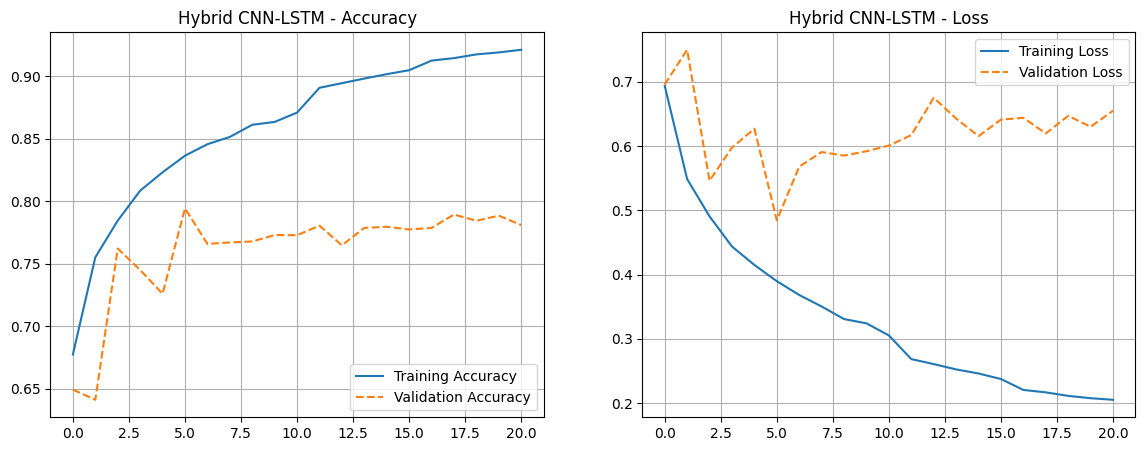

In [11]:
#MODEL CNN-LSTM
hybrid = models.Sequential([
    layers.Input(shape=hybrid_input_shape),
    layers.TimeDistributed(layers.Conv1D(64, 3, activation='relu', padding='same')),
    layers.TimeDistributed(layers.GlobalMaxPooling1D()), # Pooling theo trục thời gian con
    layers.LSTM(64),
    layers.Dense(len(FINAL_EMOTIONS), activation='softmax')
])
history_hybrid, acc_hybrid, preds_hybrid = train_eval_model(hybrid, X_train_hybrid, y_train, X_test_hybrid, y_test, "Hybrid")
results['CNN-LSTM'] = acc_hybrid

plot_training_history(history_hybrid, "Hybrid CNN-LSTM")

      Model  Accuracy
0    CNN-2D  0.830249
2  CNN-LSTM  0.794380
1      LSTM  0.702993


C:\Users\TrungKien\AppData\Local\Temp\ipykernel_4068\3333161952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_res, x='Model', y='Accuracy', palette='viridis')


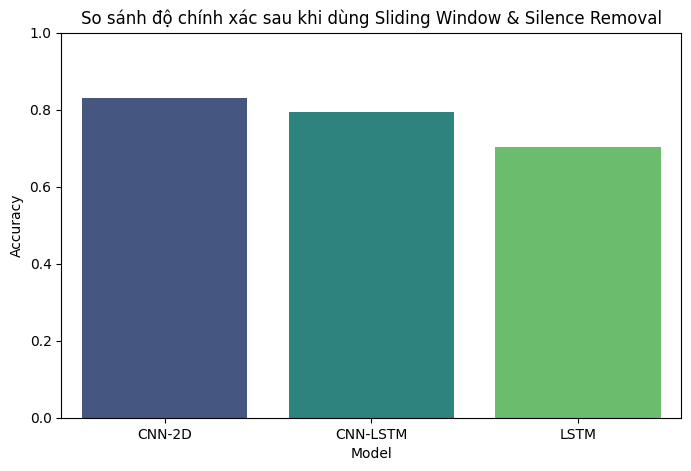

In [12]:
df_res = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print(df_res)

plt.figure(figsize=(8,5))
sns.barplot(data=df_res, x='Model', y='Accuracy', palette='viridis')
plt.title('So sánh độ chính xác sau khi dùng Sliding Window & Silence Removal')
plt.ylim(0, 1)
plt.show()

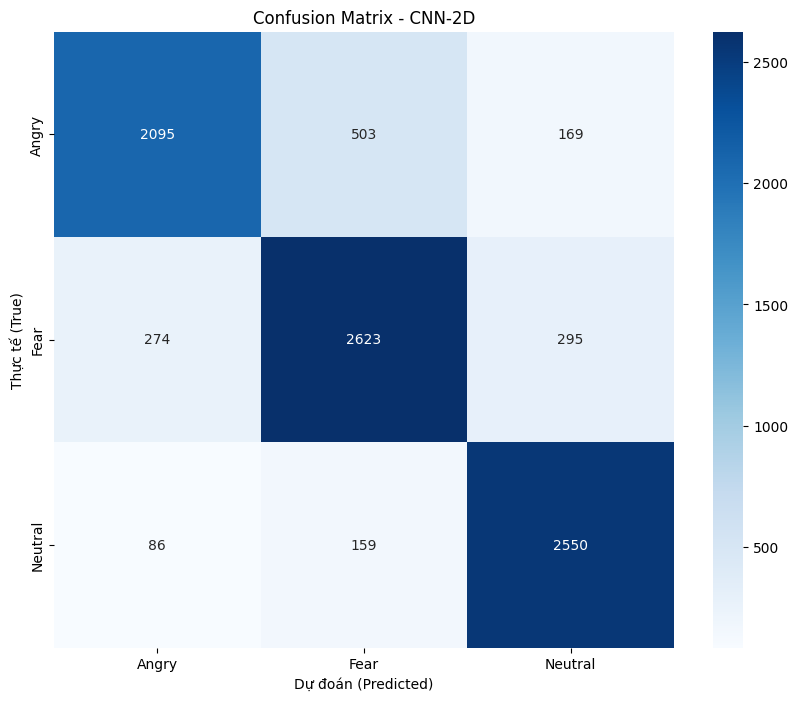


Chi tiết độ chính xác theo từng cảm xúc (CNN-2D):
              precision    recall  f1-score   support

       Angry       0.85      0.76      0.80      2767
        Fear       0.80      0.82      0.81      3192
     Neutral       0.85      0.91      0.88      2795

    accuracy                           0.83      8754
   macro avg       0.83      0.83      0.83      8754
weighted avg       0.83      0.83      0.83      8754



In [13]:
y_pred_classes = np.argmax(preds_cnn, axis=1)
y_true = np.argmax(y_test, axis=1)            
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=FINAL_EMOTIONS, yticklabels=FINAL_EMOTIONS)
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (True)')
plt.title('Confusion Matrix - CNN-2D')
plt.show()

from sklearn.metrics import classification_report
print("\nChi tiết độ chính xác theo từng cảm xúc (CNN-2D):")
print(classification_report(y_true, y_pred_classes, target_names=FINAL_EMOTIONS))